In [90]:
!pip install -q torch torchvision torchaudio scikit-learn matplotlib pandas

In [91]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report


In [92]:
SEED = 2025

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

In [93]:
data = pd.read_csv("cybersequrity.csv")

data.head()

,svcscan.fs_drivers,callbacks.ngeneric,psxview.not_in_eprocess_pool_false_avg,psxview.not_in_eprocess_pool,callbacks.nanonymous,psxview.not_in_session,psxview.not_in_pslist,psxview.not_in_pspcid_list,psxview.not_in_ethread_pool,psxview.not_in_csrss_handles,psxview.not_in_pslist_false_avg,psxview.not_in_pspcid_list_false_avg,psxview.not_in_deskthrd,psxview.not_in_ethread_pool_false_avg,psxview.not_in_session_false_avg,Class
0,26,8,0.0,0,0,2,0,0,0,4,0.000000,0.000000,6,0.000000,0.044444,1
1,26,8,0.0,0,0,5,3,3,3,7,0.073171,0.073171,9,0.073171,0.121951,1
2,26,8,0.0,0,0,9,7,7,7,11,0.152174,0.152174,13,0.152174,0.195652,1
3,26,8,0.0,0,0,3,1,1,2,6,0.022222,0.022222,9,0.044444,0.066667,1
4,26,8,0.0,0,0,2,0,0,0,4,0.000000,0.000000,6,0.000000,0.048780,0


In [94]:
data["Class"].value_counts()

,count
Class,
1,5096
0,4904


In [95]:
X = data.drop(columns=["Class"]).values
y = data["Class"].values

In [96]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    stratify=y,
    random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=SEED
)

In [97]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

In [98]:
class MalwareDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [99]:
BATCH_SIZE = 32

train_ds = MalwareDataset(X_train, y_train)
val_ds   = MalwareDataset(X_val, y_val)
test_ds  = MalwareDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

In [100]:
class BaselineMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [101]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [102]:
model = BaselineMLP(input_dim=X_train.shape[1]).to(device)

In [103]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).unsqueeze(1)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [104]:
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).unsqueeze(1)

            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            total_loss += loss.item()

    return total_loss / len(loader)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 25

train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, criterion, optimizer)
    val_loss = eval_epoch(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f}")


Epoch 1/25 | Train loss: 0.6856 | Val loss: 0.6762
Epoch 2/25 | Train loss: 0.6682 | Val loss: 0.6611
Epoch 3/25 | Train loss: 0.6502 | Val loss: 0.6485
Epoch 4/25 | Train loss: 0.6365 | Val loss: 0.6387
Epoch 5/25 | Train loss: 0.6228 | Val loss: 0.6261
Epoch 6/25 | Train loss: 0.6082 | Val loss: 0.6134
Epoch 7/25 | Train loss: 0.5935 | Val loss: 0.5996
Epoch 8/25 | Train loss: 0.5794 | Val loss: 0.5818
Epoch 9/25 | Train loss: 0.5666 | Val loss: 0.5683
Epoch 10/25 | Train loss: 0.5532 | Val loss: 0.5559
Epoch 11/25 | Train loss: 0.5407 | Val loss: 0.5539
Epoch 12/25 | Train loss: 0.5283 | Val loss: 0.5282
Epoch 13/25 | Train loss: 0.5167 | Val loss: 0.5186
Epoch 14/25 | Train loss: 0.5085 | Val loss: 0.5054
Epoch 15/25 | Train loss: 0.4995 | Val loss: 0.5044
Epoch 16/25 | Train loss: 0.4983 | Val loss: 0.4970
Epoch 17/25 | Train loss: 0.4927 | Val loss: 0.4903
Epoch 18/25 | Train loss: 0.4895 | Val loss: 0.4829
Epoch 19/25 | Train loss: 0.4850 | Val loss: 0.4815
Epoch 20/25 | Train l

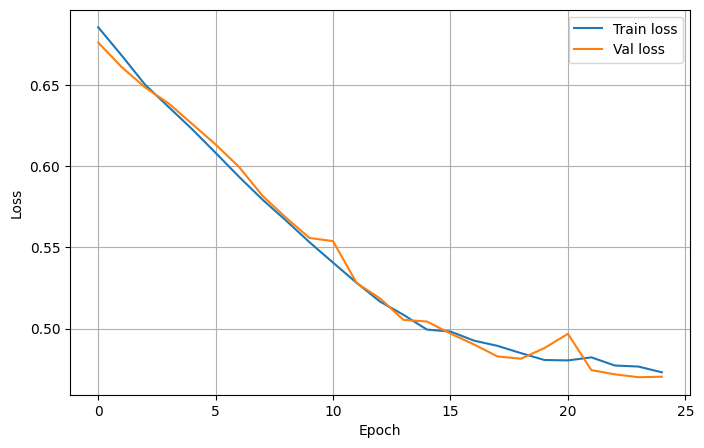

In [105]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [106]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch)
        preds = (preds.cpu().numpy() > 0.5).astype(int)

        y_true.extend(y_batch.numpy())
        y_pred.extend(preds.flatten())

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

         0.0       0.77      0.72      0.75       981
         1.0       0.75      0.80      0.77      1019

    accuracy                           0.76      2000
   macro avg       0.76      0.76      0.76      2000
weighted avg       0.76      0.76      0.76      2000



In [107]:
class BetterMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

model = BetterMLP(X_train.shape[1]).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

EPOCHS = 75


train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, criterion, optimizer)
    val_loss = eval_epoch(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"[Improved] Epoch {epoch+1}/{EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

[Improved] Epoch 1/75 | Train: 0.6781 | Val: 0.6620
[Improved] Epoch 2/75 | Train: 0.6531 | Val: 0.6415
[Improved] Epoch 3/75 | Train: 0.6325 | Val: 0.6228
[Improved] Epoch 4/75 | Train: 0.6037 | Val: 0.5856
[Improved] Epoch 5/75 | Train: 0.5721 | Val: 0.5491
[Improved] Epoch 6/75 | Train: 0.5546 | Val: 0.5385
[Improved] Epoch 7/75 | Train: 0.5396 | Val: 0.5111
[Improved] Epoch 8/75 | Train: 0.5235 | Val: 0.4936
[Improved] Epoch 9/75 | Train: 0.5136 | Val: 0.4819
[Improved] Epoch 10/75 | Train: 0.4986 | Val: 0.4663
[Improved] Epoch 11/75 | Train: 0.4875 | Val: 0.4687
[Improved] Epoch 12/75 | Train: 0.4828 | Val: 0.4506
[Improved] Epoch 13/75 | Train: 0.4760 | Val: 0.4588
[Improved] Epoch 14/75 | Train: 0.4725 | Val: 0.4528
[Improved] Epoch 15/75 | Train: 0.4684 | Val: 0.4362
[Improved] Epoch 16/75 | Train: 0.4654 | Val: 0.4369
[Improved] Epoch 17/75 | Train: 0.4585 | Val: 0.4279
[Improved] Epoch 18/75 | Train: 0.4545 | Val: 0.4282
[Improved] Epoch 19/75 | Train: 0.4531 | Val: 0.4234
[I

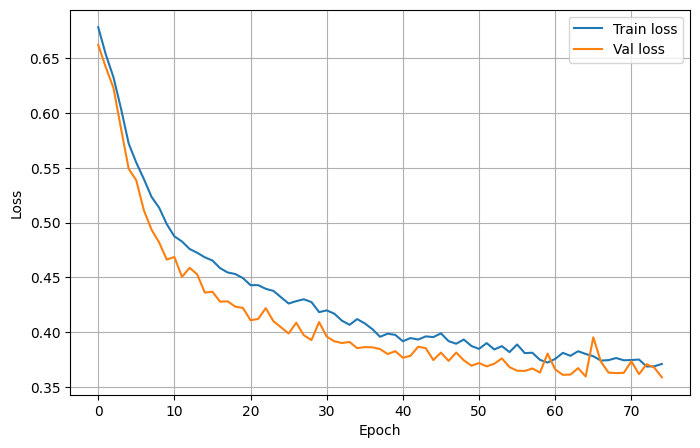

In [108]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

Добавил дропаут для предотвращения переобучению, учеличил количество эпох при уменьшении скорости обучения для предотвращения перепрыгивания оптимальных значений, взял другой лосс ибо он эмпирически себя лучше показал, добавил слои и нейроны для улучшения точности

In [109]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch)
        preds = (preds.cpu().numpy() > 0.5).astype(int)

        y_true.extend(y_batch.numpy())
        y_pred.extend(preds.flatten())

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

         0.0       0.76      0.96      0.85       981
         1.0       0.95      0.70      0.81      1019

    accuracy                           0.83      2000
   macro avg       0.85      0.83      0.83      2000
weighted avg       0.85      0.83      0.83      2000

